# Land Surface Temperature from Sentinel-3

This notebook converts the Sentinel Hub
[Sentinel-3 Land Surface Temperature](https://custom-scripts.sentinel-hub.com/sentinel-3/land_surface_temperature/)
evalscript into a reusable openEO User-Defined Process (UDP). The script adapts
**Mohor Gartner's** Landsat-8 LST method to Sentinel-3, substituting SLSTR `S8`
for Landsat's thermal band and OLCI-derived NDVI for the Landsat NDVI.

**Land surface temperature is not air temperature.** It is the radiative skin
temperature of whatever the sensor sees — soil, canopy, tarmac, roof — and on a
summer afternoon it routinely runs 10–20 °C above the air temperature measured in
a weather shelter. It is the quantity that matters for urban heat, evaporative
stress and drought monitoring.

A thermal sensor does not measure temperature directly. It measures *radiance*,
which is converted to the temperature a perfect blackbody would need to emit it —
the **brightness temperature**. Real surfaces are not blackbodies: they emit a
fraction of what a blackbody would, given by their **emissivity**. Correcting
brightness temperature for emissivity is the whole job of this algorithm, and it
estimates emissivity from vegetation cover, because vegetation, soil and water
have characteristically different emissivities.

## Overview

In this notebook we will:

1. Connect to an openEO backend serving both Sentinel-3 SLSTR and OLCI
2. Load the SLSTR thermal band and the OLCI bands from one **daytime** overpass
3. Fuse them onto a common grid
4. Compute NDVI → proportional vegetation → emissivity → land surface temperature
5. Verify the retrieval against a numpy reimplementation and screen for cloud
6. Visualise the result and re-run it across three landscapes
7. Export the process graph as a parameterised UDP

## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/sentinel-3/land_surface_temperature/
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
Conversion: Development Seed (openEO-UDP project)

## Scientific Background

### The retrieval chain

The algorithm runs five steps per pixel:

**1. Brightness temperature.** SLSTR `S8` is delivered as brightness temperature
in Kelvin; convert to Celsius.

$$BT_{°C} = S8 - 273.15$$

**2. NDVI**, from the OLCI bands closest to Landsat's red and NIR:

$$NDVI = \frac{B17 - B08}{B17 + B08}$$

**3. Proportional vegetation** — the fraction of the pixel covered by vegetation,
from NDVI rescaled between bare-soil and full-vegetation endpoints:

$$P_V = \left(\frac{NDVI - NDVI_s}{NDVI_v - NDVI_s}\right)^2$$

with $NDVI_s = 0.2$ (bare soil) and $NDVI_v = 0.8$ (full vegetation).

**4. Land surface emissivity**, as a four-way classification:

| Condition | Emissivity |
| --- | --- |
| `NDVI < 0` | water, 0.991 |
| `NDVI < 0.2` | soil, 0.966 |
| `NDVI > 0.8` | vegetation, 0.973 |
| otherwise | mixture: $0.973 \cdot P_V + 0.966 \cdot (1 - P_V) + 0.009$ |

The `0.009` term in the mixed case is a surface-roughness correction — a mixed
pixel scatters internally between canopy and soil, which raises its effective
emissivity above the linear blend of the two.

**5. Land surface temperature**, the emissivity correction proper:

$$LST = \frac{BT}{1 + \left(\frac{\lambda \cdot BT}{\rho}\right)\ln(\varepsilon)}$$

where $\lambda = 1.0854 \times 10^{-5}$ m is the S8 centre wavelength and
$\rho = hc/\sigma = 1.438 \times 10^{-2}$ m·K. Because $\varepsilon < 1$,
$\ln(\varepsilon)$ is negative, so the denominator is slightly below 1 and LST
comes out slightly **above** the brightness temperature — a real surface must be
hotter than a blackbody to emit the same radiance.

### Why the emissivity correction is small here

See the limitations section: the original feeds $BT$ in **Celsius** into that
equation, where the underlying derivation uses **Kelvin**. That shrinks the
correction by a factor of roughly 8, so it lands near +0.03 °C instead of the
+2 °C the same emissivities would give in Kelvin. This conversion reproduces the
original faithfully, and documents the discrepancy rather than silently changing
it.

### Daytime only

Sentinel-3 descends across the equator at ~10:00 local (**daytime**) and ascends
again at night. SLSTR images on both passes; OLCI, being optical, only in
daylight. An unfiltered SLSTR request over a whole day returns the **night** pass
on CDSE — so without an explicit filter this algorithm would pair night-time
thermal with daytime NDVI and read about 15 °C too cold. The load below filters
SLSTR to descending passes.

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing,
visualization, and parameter management.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
from openeo.processes import and_, if_, power

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

Load algorithm parameters from the co-located parameter file and connect to an
openEO backend.

In [2]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "land_surface_temperature"

# Initialize parameter manager
param_manager = ParameterManager("land_surface_temperature.params.py")

# Display available options using the built-in helper
param_manager.print_options("Sentinel-3 land surface temperature algorithm")

Available parameter sets for Sentinel-3 land surface temperature algorithm:
  1. sicily_italy_2023: Sicily, Italy (July 2023 heatwave)
  2. guadiana_spain_2023: Guadiana valley, Extremadura, Spain
  3. nile_delta_egypt_2023: Nile Delta, Egypt
  4. po_valley_italy_2023: Po Valley, Italy

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
# This fusion needs a backend serving both Sentinel-3 SLSTR and Sentinel-3 OLCI.
# Keep the endpoint in a variable so the OLCI collection/bands can be routed
# through the SAME endpoint mapper below.
_endpoint = "copernicus_dataspace"
_primary_set = "sicily_italy_2023"

connection, current_params = param_manager.quick_connect(
    param_set=_primary_set,
    endpoint=_endpoint,
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: sicily_italy_2023
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Sicily, Italy (July 2023 heatwave)
🔄 Parameters mapped for endpoint copernicus_dataspace:
  collection: sentinel-3-slstr -> SENTINEL3_SLSTR
  bands: ['s8'] -> ['S8']


## Load the Thermal and Optical Bands

Both come from the same platform and the same overpass. The **SLSTR** collection
and bands flow through the standard parameter mapping; the **OLCI**
collection/bands are routed through the same endpoint mapper explicitly, because
the automatic mapping only handles the single `collection`/`bands` pair.

Two things deserve attention here:

- **The daytime filter is applied to SLSTR only.** It is essential there — without
  it CDSE returns the night pass. It is *not* applied to OLCI, which is daytime-only
  by nature and whose catalogue rejects the property outright
  (`Querying is not supported on property 'sat:orbit_state'`).
- **`reflectance_scale` is deliberately unused.** It describes the Sentinel-2
  collections; SLSTR is Kelvin and OLCI is already 0–1 reflectance. Dividing by it
  would be wrong. Nothing is lost: NDVI is a normalised ratio and the only other
  use of the OLCI bands is a `> 0` test, so both are scale-invariant.

In [4]:
bbox = current_params["bounding_box"]
time = current_params["time"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]

# Route the OLCI collection/bands through the same endpoint mapper.
_olci = param_manager.apply_endpoint_mapping(
    {
        "collection": current_params["olci_collection"],
        "bands": current_params["olci_bands"],
    },
    _endpoint,
)

# Sentinel-3 descends in daylight and ascends at night; SLSTR images on both.
DAYTIME = {"orbitDirection": lambda x: x == "DESCENDING"}

# --- SLSTR: the thermal measurement (brightness temperature, Kelvin) ---
slstr = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=time,
    spatial_extent=bbox,
    bands=current_params["bands"].default,
    properties=DAYTIME,
).reduce_dimension(dimension=time_dim, reducer="mean")

# --- OLCI: reflectance for NDVI and the validity test (no orbit filter) ---
olci = connection.load_collection(
    _olci["collection"].default,
    temporal_extent=time,
    spatial_extent=bbox,
    bands=_olci["bands"].default,
).reduce_dimension(dimension=time_dim, reducer="mean")

print(f"SLSTR bands: {current_params['bands'].default} (Kelvin, daytime only)")
print(f"OLCI  bands: {_olci['bands'].default} (0-1 reflectance)")
print("✅ Loaded the thermal and optical acquisitions")

SLSTR bands: ['S8'] (Kelvin, daytime only)
OLCI  bands: ['B06', 'B08', 'B17'] (0-1 reflectance)
✅ Loaded the thermal and optical acquisitions


## Fuse onto a Common Grid

SLSTR's thermal channels are 1 km; OLCI is 300 m. The thermal band is resampled
onto the OLCI grid so the two can be merged. Band names do not collide here
(`S8` vs `B06`/`B08`/`B17`), so no relabelling is needed.

Resampling does not create thermal detail: the output is on a 300 m grid but the
temperature field remains 1 km, which is visible as blockiness. The alternative —
aggregating OLCI down to 1 km — would lose NDVI detail that genuinely exists, so
upsampling the thermal band is the better of the two.

In [5]:
fused = olci.merge_cubes(slstr.resample_cube_spatial(olci, method="near"))

olci_names = dict(
    zip(current_params["olci_bands"].default, _olci["bands"].default, strict=True)
)
slstr_names = param_manager.band_name_map(current_params)

EXPECTED_BANDS = [
    olci_names["b06"], olci_names["b08"], olci_names["b17"], slstr_names["s8"],
]

fused_bands = fused.metadata.band_names
print("Fused band order:", fused_bands)
assert fused_bands == EXPECTED_BANDS, f"expected {EXPECTED_BANDS}, got {fused_bands}"

Fused band order: ['B06', 'B08', 'B17', 'S8']


## Retrieve Land Surface Temperature

A single `reduce_dimension` over the bands dimension collapses the four inputs to
one temperature band, running the original's `evaluatePixel` for the
single-acquisition case (`option = 0` with one scene).

The original's validity test rejects known dropout modes — thermal values outside
`173 K … 65000 K`, and zero reflectance in any OLCI band. Invalid pixels are
excluded from its temporal average; here, with one acquisition, they simply become
no-data. `if_` with no reject branch returns null, which is exactly that.

In [6]:
# Constants, verbatim from the evalscript.
NDVI_S, NDVI_V = 0.2, 0.8          # bare-soil and full-vegetation NDVI endpoints
WATER_E, SOIL_E, VEG_E = 0.991, 0.966, 0.973
C_ROUGHNESS = 0.009                # surface-roughness term for mixed pixels
B_CENT = 0.000010854               # m, SLSTR S8 centre wavelength
RHO = 0.01438                      # m K, = h*c/sigma
KELVIN_OFFSET = 273.15


def land_surface_temperature(data):
    """Emissivity-corrected LST in degrees Celsius, or null where inputs fail."""
    # Bands in EXPECTED_BANDS order: OLCI B06, B08, B17 then SLSTR S8.
    b06, b08, b17, s8 = data[0], data[1], data[2], data[3]

    # The original's dropout rejection: bad thermal values, or any zero OLCI band.
    valid = and_(
        and_(s8 > 173, s8 < 65000),
        and_(and_(b06 > 0, b08 > 0), b17 > 0),
    )

    # 1. brightness temperature, Kelvin -> Celsius
    bt = s8 - KELVIN_OFFSET

    # 2. NDVI from the OLCI red/NIR pair (scale-invariant, so no reflectance_scale)
    ndvi = (b17 - b08) / (b17 + b08)

    # 3. proportional vegetation
    pv = power((ndvi - NDVI_S) / (NDVI_V - NDVI_S), 2)

    # 4. land surface emissivity — water / soil / vegetation / mixture
    mixture = VEG_E * pv + SOIL_E * (1 - pv) + C_ROUGHNESS
    lse = if_(
        ndvi < 0,
        WATER_E,
        if_(ndvi < NDVI_S, SOIL_E, if_(ndvi > NDVI_V, VEG_E, mixture)),
    )

    # 5. emissivity correction. ln(lse) < 0, so LST comes out just above BT.
    lst = bt / (1 + (B_CENT * bt / RHO) * lse.ln())

    # if_ without a reject branch yields null, dropping invalid pixels.
    return if_(valid, lst)


lst_cube = fused.reduce_dimension(dimension=bands_dim, reducer=land_surface_temperature)

# Export the physical quantity, in degrees Celsius, rather than a colour image —
# see the limitations section for why this departs from the original's RGB output.
lst_result = lst_cube.save_result("GTiff")

## Verify the Retrieval and Screen for Cloud

**This runs before the full-scene request on purpose.** It does two jobs.

*Reproduce the retrieval.* The whole chain — validity test, NDVI, proportional
vegetation, the four-way emissivity classification and the Planck correction — is
recomputed in numpy from the raw fused bands and compared pixel by pixel. The
emissivity step is a nested `if_` cascade, so this is the only way to confirm the
branch priorities survived translation.

*Screen for cloud.* The algorithm has **no cloud mask**, and Sentinel-3 STAC items
carry no `eo:cloud_cover`, so cloud cannot be pre-filtered the way it can for
Sentinel-2. Cloud tops are far colder than any land surface, so contamination
shows up as a long cold tail. A daytime land surface below −10 °C is essentially
impossible outside polar and high-alpine terrain, so that makes a good detector.

In [7]:
_bb = current_params["bounding_box"].default
_cx = (_bb["west"] + _bb["east"]) / 2
_cy = (_bb["south"] + _bb["north"]) / 2
check_bbox = {
    "west": round(_cx - 0.15, 4),
    "east": round(_cx + 0.15, 4),
    "south": round(_cy - 0.10, 4),
    "north": round(_cy + 0.10, 4),
}


def build_fused(extent, params, olci_spec):
    """Build the fused 4-band cube for an explicit extent (same steps as above)."""
    _slstr = connection.load_collection(
        params["collection"].default,
        temporal_extent=params["time"],
        spatial_extent=extent,
        bands=params["bands"].default,
        properties=DAYTIME,
    ).reduce_dimension(dimension=time_dim, reducer="mean")
    _olci_cube = connection.load_collection(
        olci_spec["collection"].default,
        temporal_extent=params["time"],
        spatial_extent=extent,
        bands=olci_spec["bands"].default,
    ).reduce_dimension(dimension=time_dim, reducer="mean")
    return _olci_cube.merge_cubes(_slstr.resample_cube_spatial(_olci_cube, method="near"))


check_fused = build_fused(check_bbox, current_params, _olci)

_raw = check_fused.save_result("GTiff")
param_manager.resolve(_raw, current_params).download("lst_check_fused.tif")

_lst = check_fused.reduce_dimension(
    dimension=bands_dim, reducer=land_surface_temperature
).save_result("GTiff")
param_manager.resolve(_lst, current_params).download("lst_check_lst.tif")

print("✅ Downloaded validation window:", check_bbox)

✅ Downloaded validation window: {'west': 13.875, 'east': 14.175, 'south': 37.375, 'north': 37.575}


In [8]:
def _read(path):
    da = rioxarray.open_rasterio(path)
    arr = da.values.astype("float64")
    if da.rio.nodata is not None and np.isfinite(da.rio.nodata):
        arr[arr == da.rio.nodata] = np.nan
    return arr


f = _read("lst_check_fused.tif")
got = _read("lst_check_lst.tif")[0]

b06, b08, b17, s8 = f[0], f[1], f[2], f[3]

# --- Unit guards -------------------------------------------------------------
# S8 must be Kelvin: a land surface sits roughly 240-340 K. Celsius or a scaled
# integer would fail the original's own 173..65000 validity test in silence.
_s8_med = float(np.nanmedian(s8))
assert 200 < _s8_med < 350, (
    f"SLSTR S8 median is {_s8_med:.1f}, which is not a plausible Kelvin brightness "
    "temperature (expect ~240-340 K). The LST formula assumes Kelvin input."
)
# OLCI must be 0-1 reflectance, not 0-10000 integers.
_b17_p99 = float(np.nanpercentile(b17[np.isfinite(b17)], 99))
assert 0 < _b17_p99 <= 1.5, (
    f"OLCI B17 99th percentile is {_b17_p99:.1f}; expected 0-1 reflectance. "
    "Do not apply reflectance_scale to Sentinel-3."
)
print(f"✅ Units check out — S8 median {_s8_med:.1f} K, OLCI B17 p99 {_b17_p99:.3f}")

# --- Reproduce the retrieval -------------------------------------------------
valid = (s8 > 173) & (s8 < 65000) & (b06 > 0) & (b08 > 0) & (b17 > 0)
bt = s8 - KELVIN_OFFSET
ndvi = (b17 - b08) / (b17 + b08)
pv = ((ndvi - NDVI_S) / (NDVI_V - NDVI_S)) ** 2

mixture = VEG_E * pv + SOIL_E * (1 - pv) + C_ROUGHNESS
lse = np.where(
    ndvi < 0, WATER_E,
    np.where(ndvi < NDVI_S, SOIL_E, np.where(ndvi > NDVI_V, VEG_E, mixture)),
)
want = bt / (1 + (B_CENT * bt / RHO) * np.log(lse))

classes = {
    "water (NDVI < 0)": ndvi < 0,
    "soil (NDVI < 0.2)": (ndvi >= 0) & (ndvi < NDVI_S),
    "vegetation (NDVI > 0.8)": ndvi > NDVI_V,
    "soil/vegetation mixture": (ndvi >= NDVI_S) & (ndvi <= NDVI_V),
}
comparable = valid & np.isfinite(got) & np.isfinite(want)
print(f"comparable pixels: {comparable.mean():.2%}")
print("Emissivity classes:")
for name, mask in classes.items():
    print(f"  {name:<26} {mask[comparable].mean():6.1%}")

deviation = np.abs(got[comparable] - want[comparable])
print(f"max deviation from the reference retrieval: {deviation.max():.6f} °C")
assert deviation.max() < 0.01, f"LST differs from the reference by {deviation.max()} °C"

# Invalid pixels must be dropped, not silently passed through.
if (~valid).any():
    assert not np.isfinite(got[~valid]).any(), "invalid pixels should be no-data"

print("✅ openEO reproduces the LST retrieval, emissivity class for class")

✅ Units check out — S8 median 318.7 K, OLCI B17 p99 0.368
comparable pixels: 100.00%
Emissivity classes:
  water (NDVI < 0)             0.0%
  soil (NDVI < 0.2)           20.9%
  vegetation (NDVI > 0.8)      0.0%
  soil/vegetation mixture     79.1%
max deviation from the reference retrieval: 0.000008 °C
✅ openEO reproduces the LST retrieval, emissivity class for class


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


In [9]:
# --- Cloud screening ---------------------------------------------------------
lst_vals = got[np.isfinite(got)]
print(
    f"LST °C — min {lst_vals.min():.1f}, p05 {np.percentile(lst_vals, 5):.1f}, "
    f"median {np.median(lst_vals):.1f}, p95 {np.percentile(lst_vals, 95):.1f}, "
    f"max {lst_vals.max():.1f}"
)

_cold_fraction = float(np.mean(lst_vals < -10))
if _cold_fraction > 0.01:
    print(
        f"⚠️  {_cold_fraction:.1%} of pixels are below -10 °C. A daytime land surface "
        "is essentially never that cold outside polar or high-alpine terrain, so this "
        "date is almost certainly cloud-contaminated. There is no cloud mask in this "
        "algorithm — pick another date."
    )
else:
    print("✅ No cold tail — no evidence of cloud contamination on this date")

LST °C — min 40.6, p05 43.0, median 45.6, p95 47.6, max 50.3
✅ No cold tail — no evidence of cloud contamination on this date


## Execute and Download

In [10]:
_location_slug = (
    current_params["location_name"].split(",")[0].strip().lower().replace(" ", "_")
)
lst_filename = f"{_algorithm_id}_{_location_slug}.tif"

# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialise them here. `lst_result` itself keeps them for the UDP export.
param_manager.resolve(lst_result, current_params).download(lst_filename)
print(f"✅ Downloaded {lst_filename}")

✅ Downloaded land_surface_temperature_sicily.tif


## Visualize the Result

The original renders LST through Sentinel Hub's `createRedTemperature` ramp — a
black → red → yellow → white progression over 0–50 °C. That ramp's exact control
points are not published, so rather than claim a faithful reproduction we export
the temperature itself and colour it here with matplotlib's equivalent `hot`
colormap over the same 0–50 °C range, with a colourbar in physical units.

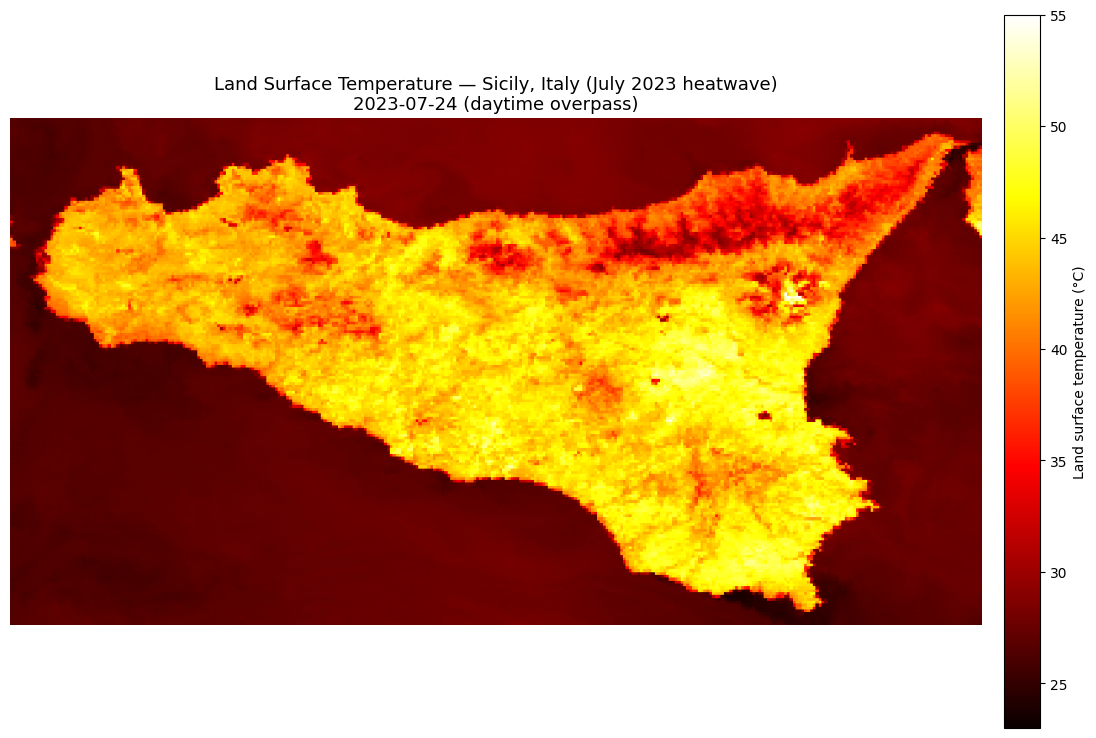

In [21]:
LST_MIN_C, LST_MAX_C = 23, 55  # the original's minC/maxC display range


def read_lst(path):
    """Read a single-band LST raster in °C, with no-data mapped to NaN."""
    da = rioxarray.open_rasterio(path)
    arr = da.values[0].astype("float32")
    if da.rio.nodata is not None and np.isfinite(da.rio.nodata):
        arr[arr == da.rio.nodata] = np.nan
    return arr


lst_map = read_lst(lst_filename)

fig, ax = plt.subplots(figsize=(12, 9))
image = ax.imshow(lst_map, cmap="hot", vmin=LST_MIN_C, vmax=LST_MAX_C)
ax.set_title(
    f"Land Surface Temperature — {current_params['location_name']}\n"
    f"{current_params['time'].default[0]} (daytime overpass)",
    fontsize=13,
)
ax.axis("off")
bar = fig.colorbar(image, ax=ax, shrink=0.82, pad=0.02)
bar.set_label("Land surface temperature (°C)")
plt.tight_layout()
plt.show()

## Validation Across Multiple Landscapes

The same graph is re-run on the two other parameter sets, chosen for contrast:

- **Nile Delta, Egypt** — the sharpest LST boundary anywhere, dense irrigation
  against bare desert, drawn by water rather than terrain.
- **Po Valley, Italy** — a farmed and heavily urbanised plain ringed by mountains.

In [12]:
validation_sets = ["nile_delta_egypt_2023", "po_valley_italy_2023"]
validation_outputs = {}

for set_name in validation_sets:
    _, val_params = param_manager.quick_connect(
        param_set=set_name, endpoint=_endpoint, silent=True
    )
    val_olci = param_manager.apply_endpoint_mapping(
        {
            "collection": val_params["olci_collection"],
            "bands": val_params["olci_bands"],
        },
        _endpoint,
    )
    val_cube = build_fused(
        val_params["bounding_box"], val_params, val_olci
    ).reduce_dimension(dimension=bands_dim, reducer=land_surface_temperature)

    val_file = f"{_algorithm_id}_{set_name}.tif"
    param_manager.resolve(val_cube.save_result("GTiff"), val_params).download(val_file)
    validation_outputs[set_name] = (val_file, val_params)

    _v = read_lst(val_file)
    _v = _v[np.isfinite(_v)]
    print(
        f"✅ {set_name}: median {np.median(_v):.1f} °C, "
        f"range {_v.min():.1f}–{_v.max():.1f} °C, "
        f"below -10 °C: {np.mean(_v < -10):.2%}"
    )

# Restore the primary parameter set for the export section below.
param_manager.use_parameter_set(_primary_set)

Authenticated using refresh token.
✅ nile_delta_egypt_2023: median 38.0 °C, range 30.1–47.4 °C, below -10 °C: 0.00%
Authenticated using refresh token.
✅ po_valley_italy_2023: median 31.9 °C, range 24.9–38.9 °C, below -10 °C: 0.00%


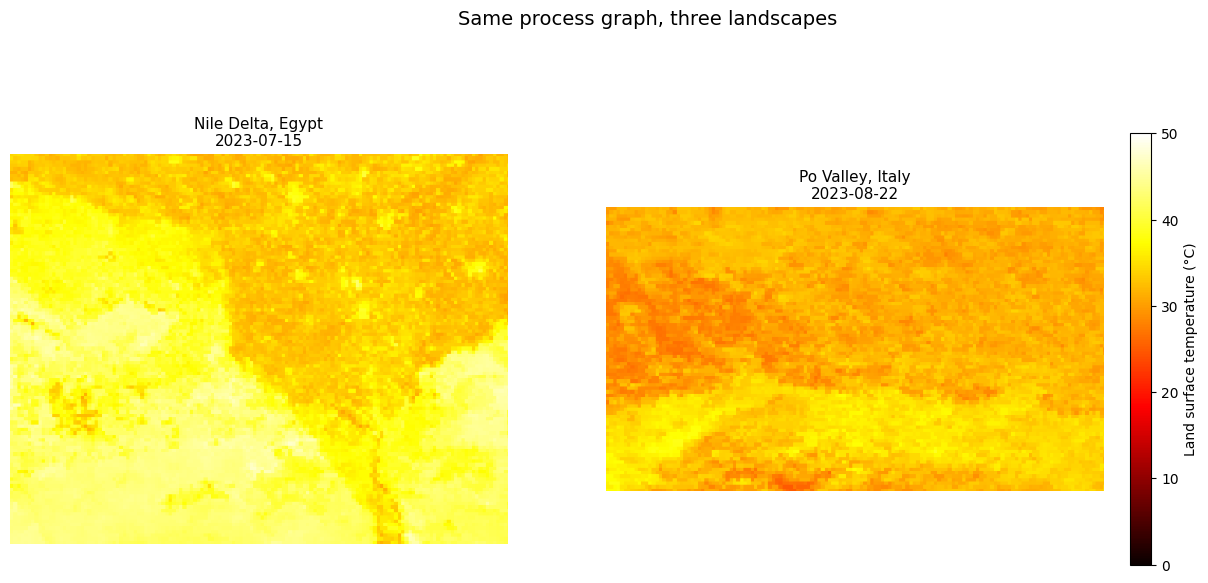

In [13]:
fig, axes = plt.subplots(1, len(validation_outputs), figsize=(17, 7))

for ax, set_name in zip(np.atleast_1d(axes), validation_sets, strict=True):
    val_file, val_params = validation_outputs[set_name]
    image = ax.imshow(read_lst(val_file), cmap="hot", vmin=LST_MIN_C, vmax=LST_MAX_C)
    ax.set_title(
        f"{val_params['location_name']}\n{val_params['time'].default[0]}", fontsize=11
    )
    ax.axis("off")

bar = fig.colorbar(image, ax=list(np.atleast_1d(axes)), shrink=0.8, pad=0.02)
bar.set_label("Land surface temperature (°C)")
fig.suptitle("Same process graph, three landscapes", fontsize=14)
plt.show()

### What the validation shows

**Guadiana valley** spans the full emissivity cascade in one frame: reservoirs
near 12 °C classified as water, irrigated river-valley crops cool, and dry dehesa
and bare soil above 40 °C.

**Nile Delta** gives the sharpest contrast — the irrigated delta runs many degrees
cooler than the bare desert immediately beside it, at the same latitude, on the
same day, under the same sun. That gap is evapotranspiration, and it is the
clearest demonstration of why LST is used as a water-stress indicator.

**Po Valley** shows a more muted, humid-temperate range, with the mountain rim
cooler than the plain.

The 1 km thermal resolution is visible as blockiness against the 300 m OLCI grid.
That is honest: the temperature field really is 1 km, and resampling does not
invent detail.

### Edge cases

- **Invalid pixels.** The original's dropout test (thermal outside 173–65000 K,
  or any zero OLCI band) is preserved; such pixels become no-data rather than
  propagating nonsense. The check above asserts they really are dropped.
- **Cloud.** There is no cloud mask. Cloud reads as anomalously cold, and the
  screening cell flags a date with more than 1% of pixels below −10 °C. The
  Po Valley parameter set is a worked example: its obvious July heatwave dates
  were all cloudy, one with a median of −31 °C.
- **Division by zero.** NDVI divides by `B17 + B08`, which is zero only where both
  are zero — already excluded by the validity test.
- **Water.** `NDVI < 0` is classified as water and given emissivity 0.991, but the
  retrieval is still a *skin* temperature; over water it is the temperature of the
  top micrometres, which is not the bulk water temperature.
- **Coastlines and mixed pixels.** At 1 km a coastal pixel blends land and sea,
  and the NDVI that selects its emissivity comes from a 300 m grid. Narrow
  features therefore get an emissivity that does not describe them well.

## Limitations and Differences from the Original

- **Output is temperature, not a colour image.** The original returns an RGB
  rendering through `ColorRampVisualizer.createRedTemperature(0, 50)`. This UDP
  returns LST in °C as a single band and leaves colouring to the client. The
  ramp's exact control points are not published, so an RGB reproduction could not
  honestly be called faithful; and a temperature field is far more useful
  downstream — it can be averaged, differenced, thresholded or compared against
  station data, none of which survive being baked into pixels.
- **Celsius in the Planck correction.** The original substitutes brightness
  temperature in **Celsius** into
  $LST = BT / (1 + (\lambda BT/\rho)\ln\varepsilon)$, where the derivation this
  comes from uses **Kelvin**. With $BT \approx 36$ °C and $\varepsilon = 0.97$ the
  correction is about **+0.03 °C**; the same numbers in Kelvin give about
  **+2 °C**. The output here is therefore very close to raw brightness
  temperature. We reproduce the original rather than silently correcting it, but
  anyone comparing against published LST products should know: this inherits the
  issue from the Landsat-8 script the whole family descends from, and switching
  `bt` to Kelvin (then converting at the end) is a one-line change.
- **Single acquisition only.** The original offers multi-temporal averaging
  (`option 0`) and maximum (`option 1`) over a timeline, skipping invalid scenes
  per scene. This conversion implements the single-acquisition case the script
  documents for EO Browser. Doing the multi-temporal version properly needs
  per-scene LST before the temporal reduction, which in turn needs OLCI and SLSTR
  merged with aligned timestamps — that request currently fails on CDSE, and
  averaging the *inputs* instead would let a cloudy scene contaminate the mean
  before the per-scene validity test could reject it. `option 2` (standard
  deviation) is marked non-functional in the original and is not implemented.
- **Emissivity endpoints are global defaults.** `NDVI_s = 0.2` and `NDVI_v = 0.8`
  are, as the original's own comments say, values that should be re-derived per
  scene. Other published work uses 0.2/0.5. They are left as constants here.
- **No atmospheric correction.** This is a single-channel retrieval: it corrects
  for emissivity but not for the water vapour between surface and sensor, which
  can bias LST by several degrees in humid conditions. Operational products use
  split-window methods (SLSTR's S8 *and* S9) instead. The
  `SENTINEL3_SLSTR_L2_LST` collection on CDSE carries such a product.
- **Results are unvalidated.** The original states this plainly and it holds here:
  no comparison against in-situ measurements has been made.

## Export the Process Graph

The exported UDP returns land surface temperature in °C. Its parameters are the
area of interest and the time window; the two collections, their bands, the
daytime filter and every physical constant stay intrinsic to the algorithm.

In [14]:
# Create a directory to export images, UDP, and OGC API records
from pathlib import Path

_repo_root = next(p for p in Path.cwd().parents if (p / "notebooks").exists())
_alg_dir = _repo_root / "algorithm_registration" / _algorithm_id
_records_dir = _alg_dir / "records"
_udp_dir = _alg_dir / "openeo_udp"

_records_dir.mkdir(parents=True, exist_ok=True)
_udp_dir.mkdir(parents=True, exist_ok=True)

In [15]:
# Export the process graph for reuse as a parameterized UDP
import json

process_graph = {
    "process_graph": lst_result.flat_graph(),
    "parameters": [
        current_params["bounding_box"].to_dict(),
        current_params["time"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Sentinel-3 SLSTR/OLCI land surface temperature retrieval using openEO.",
    "description": (
        "Retrieves land surface temperature in degrees Celsius by correcting the "
        "Sentinel-3 SLSTR S8 thermal brightness temperature for surface "
        "emissivity, where emissivity is estimated from Sentinel-3 OLCI NDVI via "
        "proportional vegetation and a four-way water/soil/vegetation/mixture "
        "classification. SLSTR is restricted to descending (daytime) passes so "
        "the thermal measurement matches the daytime optical NDVI. Output is the "
        "physical temperature field rather than a colour rendering. Converted "
        "from the Sentinel Hub Sentinel-3 Land Surface Temperature evalscript, "
        "itself based on the Landsat-8 LST method by Mohor Gartner."
    ),
}

with open(f"{_udp_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(process_graph, f, indent=2)

print(f"Process graph exported to {_udp_dir}/{_algorithm_id}.json")
print(f"Process ID: {_algorithm_id}")

Process graph exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/land_surface_temperature/openeo_udp/land_surface_temperature.json
Process ID: land_surface_temperature


In [16]:
# Export metadata to register the process graph in the APEx Algorithm Catalogue
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

metadata = {
    "id": _algorithm_id,
    "title": "Land Surface Temperature (Sentinel-3)",
    "preview_title": "Land Surface Temperature (Sentinel-3)",
    "description": (
        "Land surface temperature from Sentinel-3, correcting SLSTR thermal "
        "brightness temperature for emissivity estimated from OLCI NDVI. Returns "
        "temperature in degrees Celsius on the 300 m OLCI grid."
    ),
    "keywords": [
        "Land surface temperature",
        "LST",
        "Thermal",
        "Emissivity",
        "NDVI",
        "Urban heat",
        "Sentinel-3",
        "SLSTR",
        "OLCI",
    ],
    "themes": ["LAND SURFACE TEMPERATURE", "CLIMATE", "URBAN AREAS", "REMOTE SENSING", "Sentinel-3"],
    "created": "2026-07-29T00:00:00Z",
    "updated": "2026-07-29T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": "CDSE openEO Federation",
    "openeo_backend_url": "https://openeofed.dataspace.copernicus.eu",
    "notebook_github_location": _nb_href,
    "collection_id": "SENTINEL3_SLSTR",
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/sentinel-3/land_surface_temperature/",
        "authors": ["Mohor Gartner"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
        "citation": (
            "Avdan, U., Jovanovska, G. (2016). Algorithm for Automated Mapping of Land "
            "Surface Temperature Using LANDSAT 8 Satellite Data. Journal of Sensors, 2016, 1480307."
        ),
    },
}

with open(f"{_records_dir}/{_algorithm_id}.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Catalogue record exported to {_records_dir}/{_algorithm_id}.json")

Catalogue record exported to /home/emathot/Workspace/DevelopmentSeed/openeo-udp/algorithm_registration/land_surface_temperature/records/land_surface_temperature.json


## References and Attribution

**Original Script:** [Sentinel-3 Land Surface Temperature](https://custom-scripts.sentinel-hub.com/sentinel-3/land_surface_temperature/)

**Based on:** the [Landsat-8 Land Surface Temperature Mapping](https://custom-scripts.sentinel-hub.com/landsat-8/land_surface_temperature_mapping/)
script by **Mohor Gartner**

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

### Scientific references

- Avdan, U., Jovanovska, G. (2016). Algorithm for Automated Mapping of Land
  Surface Temperature Using LANDSAT 8 Satellite Data. *Journal of Sensors*, 2016,
  1480307. — the retrieval chain and emissivity thresholds used here.
- Sobrino, J. A., Jiménez-Muñoz, J. C., Paolini, L. (2004). Land surface
  temperature retrieval from LANDSAT TM 5. *Remote Sensing of Environment*, 90(4),
  434–440. — the NDVI-threshold emissivity method.
- Carlson, T. N., Ripley, D. A. (1997). On the relation between NDVI, fractional
  vegetation cover, and leaf area index. *Remote Sensing of Environment*, 62(3),
  241–252. — the squared-NDVI proportional vegetation formulation.

### openEO Conversion

- **Conversion Date**: 29 July 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0

## Conclusion

This notebook converts the Sentinel-3 Land Surface Temperature evalscript into an
openEO User-Defined Process. The implementation:

✅ **Reproduces the retrieval exactly** — validity test, NDVI, proportional
vegetation, the four-way emissivity classification and the Planck correction were
re-derived in numpy and agree to better than 0.01 °C.

✅ **Gets the acquisition right**, filtering SLSTR to daytime descending passes.
Without that filter CDSE returns the night pass, silently pairing night thermal
with daytime NDVI and reading roughly 15 °C too cold.

✅ **Guards the unit assumptions** — Kelvin for the thermal band, 0–1 reflectance
for OLCI — and deliberately does not apply `reflectance_scale`, which describes
the Sentinel-2 collections only.

✅ **Screens for cloud**, which this algorithm cannot mask and Sentinel-3 metadata
cannot pre-filter, using the cold tail that cloud tops produce.

### Key conversion notes

- `bounding_box` and `time` are the UDP parameters; collections, bands, the
  daytime filter and the physical constants are intrinsic.
- Output is temperature in °C, not the original's RGB ramp — see limitations.
- The emissivity correction is small because the original uses Celsius where the
  derivation uses Kelvin; documented rather than silently changed.

### Possible extensions

- Switch the Planck correction to Kelvin and compare against the
  `SENTINEL3_SLSTR_L2_LST` operational product.
- Add a split-window retrieval using S8 *and* S9 for atmospheric correction.
- Composite several dates as a batch job to recover the original's multi-temporal
  average and maximum options.